In [5]:
import time
import math
import numpy as np 
import pandas as pd 
import datetime
import scipy as sc 
import matplotlib.pyplot as plt 
from IPython.display import display, Latex 
from statsmodels.graphics.tsaplots import plot_acf 
import yfinance as yf


In [3]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 33.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 15.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
# importing data
def get_data(stocks, start, end):
    df = yf.download(stocks, start, end)
    # df = df[["Close"]]    -- we just need close column to find the volatility but still we display all columns
    return df
endDate = datetime.datetime.now()
startDate = endDate - datetime.timedelta(days=7000)

stock_prices = get_data("^GSPC", startDate, endDate)
print(startDate)
stock_prices.head()

[*********************100%***********************]  1 of 1 completed

2007-02-01 12:55:12.180758


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2007-02-01,1445.939941,1446.640015,1437.900024,1437.900024,2914890000
2007-02-02,1448.390015,1449.329956,1444.489990,1445.939941,2569450000
2007-02-05,1446.989990,1449.380005,1443.849976,1448.329956,2439430000
2007-02-06,1448.000000,1450.189941,1443.400024,1446.979980,2608710000
2007-02-07,1450.020020,1452.989990,1446.439941,1447.410034,2618820000


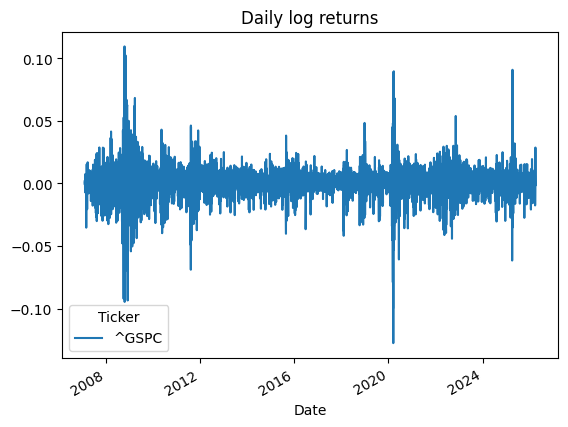

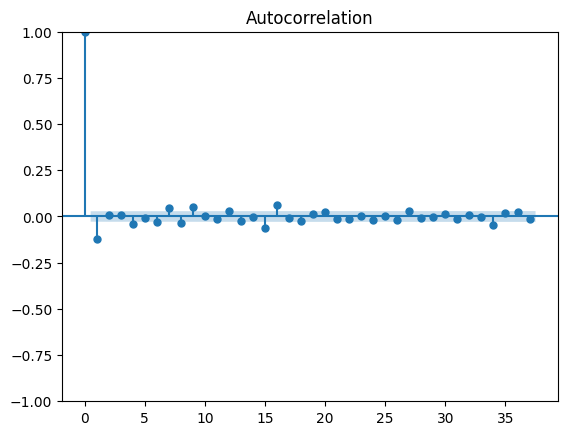

In [19]:
log_returns = np.log(stock_prices.Close/stock_prices.Close.shift(1)).dropna()
log_returns.plot()
plt.title("Daily log returns")
plot_acf(log_returns)
plt.show()

The above code computes daily log returns, visualizes them, 
and checks whether returns are autocorrelated (predictable).

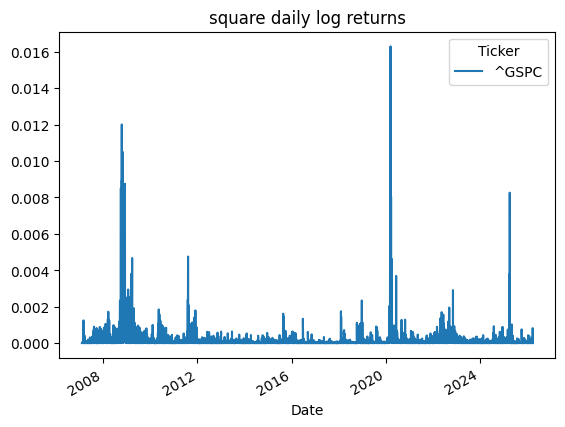

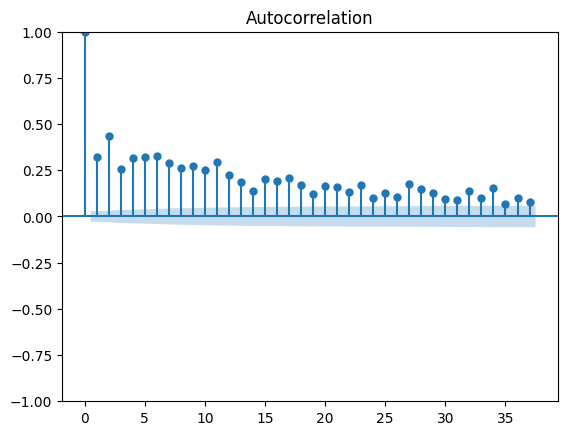

In [21]:
log_returns_sq = np.square(log_returns)
log_returns_sq.plot()
plt.title('square daily log returns')
plot_acf(log_returns_sq)
plt.show()

Squared returns reveal volatility clustering, and their autocorrelation shows that 
volatility is persistent and potentially mean-reverting.

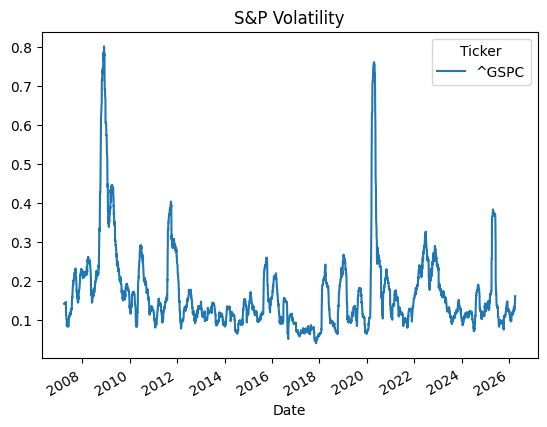

In [22]:
TRADING_DAYS = 40
volatility = log_returns.rolling(window=TRADING_DAYS).std()*np.sqrt(252)
volatility = volatility.dropna()
volatility.plot()
plt.title("S&P Volatility")
plt.show()

Here, we created an annulaized rolling volatility series that captures market risk dynamics and it ready for OU Modeling. 
Also, Our code computes a rolling 40-days standard deviation of log returns and scales it to annual volatility using sqrt(252) or 16

In [27]:
# This function computes the MLE(maximum likelihood estimate) estimates of mean and variance assuming our data follows a normal distribution. 
def MLE_norm(x):
    mu_hat = np.mean(x)
    sigma2_hat = np.var(x)
    return mu_hat, sigma2_hat

$$
\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i

$$
$$
\hat{\sigma}^2_{} = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2

$$



In [44]:
mu = 5
sigma = 2.5
N = 10000

np.random.seed(0)
x = np.random.normal(loc=mu, scale=sigma, size=(N, ))

mu_hat , sigma2_hat = MLE_norm(x)

for_mu_hat = '$\hat{\mu} = '+format(round(mu_hat, 2)) + '$'
for_sigma2_hat = '$\hat{\sigma} = '+format(round(np.sqrt(sigma2_hat),2))+'$'

print("The MLE for data is: ")
display(Latex(for_mu_hat))
display(Latex(for_sigma2_hat))

# This code simulates normal data and verifies that our MLE estimator correctly recovers the true mean and variance. 

The MLE for data is: 


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [47]:
def log_likelihood(theta, x):
    mu = theta[0]
    sigma = theta[1]

    l_theta = np.sum(np.log(sc.stats.norm.pdf(x, loc=mu, scale=sigma)))

    return -l_theta  # here negative sign indicates that optimization usually minimizes, not maximize


def sigma_pos(theta):
    sigma = theta[1]
    return sigma


# This code defines a negative log-likelihood function for a normal distribution and esnure σ (sigma) stays positive during optimization.

In [49]:
cons_set = {'type': 'ineq', 'fun': sigma_pos}  # σ >= 0, ensures valid S.D

theta0 = [2,3]
opt = sc.optimize.minimize(
    fun=log_likelihood, 
    x0=theta0, 
    args=(x, ), 
    constraints=cons_set
    )

for_mu_hat = '$\hat{\mu} = ' +format(round(opt.x[0],2))+'$'
for_sigma2_hat = '$\hat{\sigma} = ' +format(round(opt.x[1],2))+'$'

print("The MLE for data is: ")
display(Latex(for_mu_hat))
display(Latex(for_sigma2_hat))

# Here, we used numerical optimization to estimate the parameters of a normal distribution by maximizing the log_likelihood.

The MLE for data is: 


/var/folders/qb/y15c8p3j2v5122w7hy2sn6g80000gn/T/ipykernel_17765/2508010835.py:5: RuntimeWarning: divide by zero encountered in log
  l_theta = np.sum(np.log(sc.stats.norm.pdf(x, loc=mu, scale=sigma)))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [54]:
def mu(x, dt, kappa, theta):
    ekt = np.exp(-kappa*dt)
    return x*ekt + theta*(1-ekt)

def std(dt, kappa, sigma):
    e2kt = np.exp(-2*kappa*dt)
    return sigma*np.sqrt((1-e2kt) /(2*kappa))

# These functions helps to compute the exact mean and standard deviation of the OU process over a time step dt.

In [55]:
def log_likelihood_OU(theta_hat, x):
    kappa = theta_hat[0]
    theta = theta_hat[1]
    sigma = theta_hat[2]

    x_dt = x[1:]
    x_t = x[:-1]

    dt = 1/252

    mu_OU = mu(x_t, dt, kappa, theta)
    sigma_OU = std(dt, kappa, sigma)

    l_theta_hat = np.sum(np.log(sc.stats.norm.pdf(x_dt, loc=mu_OU, scale=sigma_OU)))

    return -l_theta_hat


def kappa_pos(theta_hat):
    kappa = theta_hat[0]
    return kappa

def sigma_pos(theta_hat):
    sigma = theta_hat[2]
    return sigma

# Our function computes the negative log-likelihood of the observed volatility series under the exact OU transition model,
# so we can estimate Kappa, Theta, sigma by optimization...

In [56]:
vol = np.array(volatility)

In [57]:
cons_set= [{'type': 'ineq', 'fun': kappa_pos},
           {'type': 'ineq', 'fun': sigma_pos}]

theta0 =[1,3,1]

opt = sc.optimize.minimize(fun=log_likelihood_OU, x0=theta0, args=(vol,), constraints=cons_set)

opt

# This code estimates the OU parameters kappa, Theta, and sigma for our volatility series by maximum likelihood under positivity constraints.

/var/folders/qb/y15c8p3j2v5122w7hy2sn6g80000gn/T/ipykernel_17765/2446958079.py:14: RuntimeWarning: divide by zero encountered in log
  l_theta_hat = np.sum(np.log(sc.stats.norm.pdf(x_dt, loc=mu_OU, scale=sigma_OU)))


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -16753.02010880673
           x: [ 5.712e-01  1.697e-01  1.157e-01]
         nit: 38
         jac: [ 1.709e-03  1.343e-02  2.505e-01]
        nfev: 166
        njev: 35
 multipliers: [ 0.000e+00  0.000e+00]

In [65]:
kappa=round(opt.x[0],3)
theta=round(opt.x[1],3)
sigma=round(opt.x[2],3)
vol0 = vol[-1]

for_kappa_hat = '$\hat{\kappa} = '+str(kappa)+'$'
for_theta_hat = '$\hat{\\theta} = '+str(theta)+'$'
for_sigma_hat = '$\hat{\sigma} = '+str(sigma)+'$'

print("The MLE for data is:")
display(Latex(for_kappa_hat))
display(Latex(for_theta_hat))
display(Latex(for_sigma_hat))
vol0 = vol[-1].item()
print('Last Volatility', round(vol0, 3))

# Here, we extract and displays the estimated OU parameters and current volatility, preparing us for simulation and forecasting

The MLE for data is:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Last Volatility 0.161


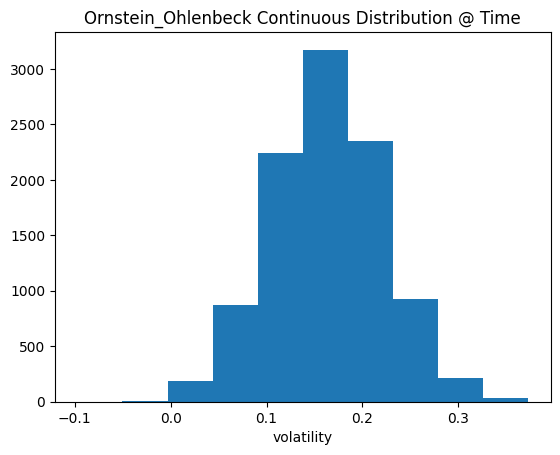

In [66]:
# Define parameters
Time = 0.3
M = 10000

Z = np.random.normal(size=(M))

def mu(x, dt, kappa, theta):
    ekt = np.exp(-kappa*dt)
    return x*ekt + theta*(1-ekt)

def std(dt, kappa, sigma):
    e2kt = np.exp(-2*kappa*dt)
    return sigma*np.sqrt((1-e2kt)/(2*kappa))

drift_OU = mu(vol0, Time, kappa, theta)
diffusion_OU = std(Time, kappa, sigma)
vol_OU = drift_OU + diffusion_OU*Z

plt.hist(vol_OU)
plt.title("Ornstein_Ohlenbeck Continuous Distribution @ Time")
plt.xlabel('volatility')
plt.show()

In [67]:
# Initiated parameters for discretization
days=1
years=2
dt = days/252

M=1000
N = int(years/dt)

# Here, we defined a daily time grid over 2 years and set up 1000 simulaiton paths for the OU process. 

# Recursive Function

Execution time 0.005881786346435547


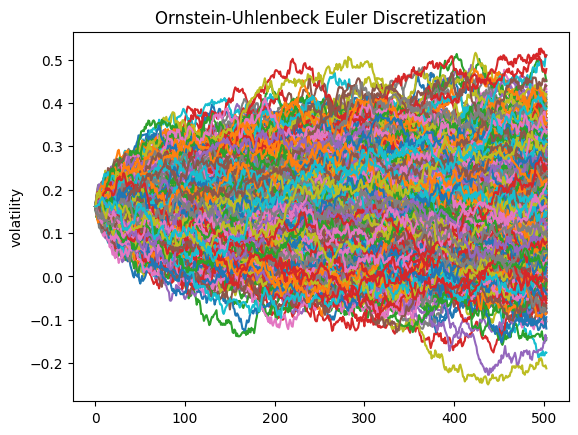

In [74]:
vol_OU = np.zeros((N, M))
vol_OU[0] = vol0

Z = np.random.normal(size=(N, M))

start_time = time.time()

for t in range(1, N):
    drift_OU = kappa * (theta - vol_OU[t-1]) * dt
    diffusion_OU = sigma * np.sqrt(dt)
    vol_OU[t] = vol_OU[t-1] + drift_OU + diffusion_OU * Z[t]

print("Execution time", time.time() - start_time)

plt.plot(vol_OU)
plt.title("Ornstein-Uhlenbeck Euler Discretization")
plt.ylabel("volatility")
plt.show()

# Python Loop

Execution time 0.0029456615447998047


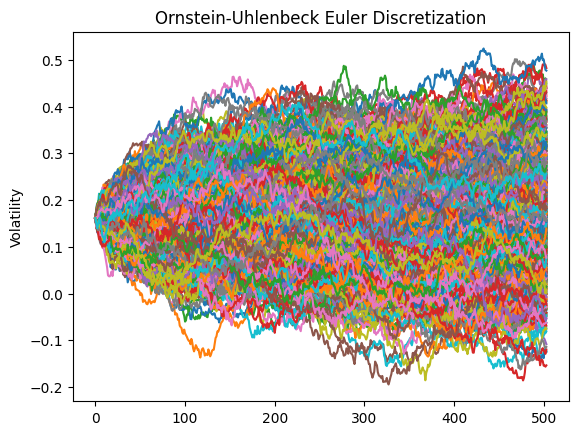

In [75]:
vol_OU = np.full(shape=(N, M), fill_value=vol0)
Z = np.random.normal(size=(N, M))

start_time = time.time()

for t in range(1, N):
    drift_OU = kappa * (theta - vol_OU[t-1]) * dt
    diffusion_OU = sigma * np.sqrt(dt)
    vol_OU[t] = vol_OU[t-1] + drift_OU + diffusion_OU * Z[t]

print('Execution time', time.time() - start_time)

plt.plot(vol_OU)
plt.title('Ornstein-Uhlenbeck Euler Discretization')
plt.ylabel("Volatility")
plt.show()